# Resonator and Qubit Spectroscopy with HDAWG and UHFQA

This notebook demonstrates pulsed resonator and pulsed qubit spectroscopy experiments with the HDAWG and UHFQA.
In contrast to the SHF instruments, which can sweep their oscillator frequencies in real time (see [this notebook](https://docs.zhinst.com/labone_q_user_manual/applications_library/how-to-guides/sources/01_superconducting_qubits/02_pulse_sequences/01_tuneup/01_cw_resonator_spec_shfsg_shfqa_shfqc.html)), HDAWG and UHFQA require sweeps in near time.

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
from pathlib import Path

# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 4

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "dio": "DEV2001",
            "options": None,
        }
    ],
    uhfqa=[{"serial": "DEV2001", "readout_multiplex": 6}],
    include_flux_lines=False,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_fixed_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 13:58:37.572] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 13:58:37.574] INFO    VERSION: laboneq 26.4.0
[2026.06.26 13:58:37.575] INFO    Connecting to data server at localhost:8004
[2026.06.26 13:58:37.576] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 13:58:37.577] INFO    Configuring the device setup
[2026.06.26 13:58:37.592] INFO    The device setup is configured


## 2. Pulsed Resonator Spectroscopy

Find the resonance frequency of the qubit readout resonator by looking at the transmission or reflection of a probe signal applied through the readout line.

### 2.1 Experiment Definition

In [4]:
# define sweep parameter - sweep over frequency of readout pulse
start = -300e6
stop = 300e6
count = 21

frequency_sweep_parameter = LinearSweepParameter(
    uid="frequency_sweep", start=start, stop=stop, count=count
)

# define number of averages
average_exponent = 4  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment - uses only a readout pulse and a data acquisition line
exp_spec = Experiment(
    uid="Resonator Spectroscopy",
    signals=[
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)

## experimental pulse sequence
# Define an acquisition loop of type SPECTROSCOPY
with exp_spec.sweep(uid="sweep", parameter=frequency_sweep_parameter):
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, average_exponent),
        averaging_mode=AveragingMode.SEQUENTIAL,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # readout pulse and data acquisition
        with exp_spec.section(uid="spectroscopy"):
            exp_spec.play(
                signal="measure", pulse=pulse_library.const(length=1e-6, amplitude=1.0)
            )
            exp_spec.acquire(
                signal="acquire",
                handle="ac_0",
                length=1e-6,
            )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp_spec.section(uid="relax"):
            exp_spec.delay(signal="measure", time=1e-6)

In [5]:
# calibration for qubit 0
calib_q0 = Calibration()
readout_acquire_oscillator = Oscillator(
    frequency=frequency_sweep_parameter,
    modulation_type=ModulationType.HARDWARE,
)
calib_q0["measure"] = SignalCalibration(
    oscillator=readout_acquire_oscillator,
    range=1.5,
)
calib_q0["acquire"] = SignalCalibration(
    oscillator=readout_acquire_oscillator,
    range=1.5,
)

In [6]:
# signal map for qubit 0
map_q0 = {
    "measure": "/logical_signal_groups/q0/measure",
    "acquire": "/logical_signal_groups/q0/acquire",
}

### 2.2 Run the Experiment and Plot the Measurement Results and Pulse Sequence

[2026.06.26 13:58:37.614] INFO    Starting LabOne Q Compiler run...
[2026.06.26 13:58:37.615] INFO    Schedule completed. [0.000 s]
[2026.06.26 13:58:37.619] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.06.26 13:58:37.619] INFO    Completed compilation step 1 of 21. [0.004 s]
[2026.06.26 13:58:37.620] INFO    Skipping compilation for next step(s)...
[2026.06.26 13:58:37.623] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 13:58:37.623] INFO      Device    AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 13:58:37.624] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 13:58:37.624] INFO      uhfqa_0     0         11            0           1      3600  
[2026.06.26 13:58:37.624] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 13:58:37.624] INFO      TOTAL                 11            0                  3600  
[2026.06.26 13:58:37.625] INFO     ──────

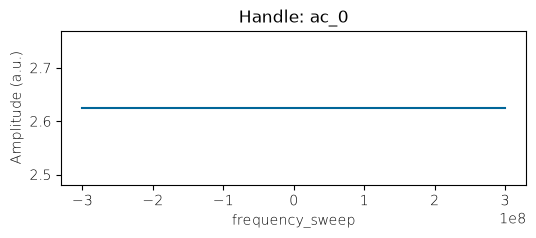

In [7]:
# set experiment calibration and signal map
exp_spec.set_calibration(calib_q0)
exp_spec.set_signal_map(map_q0)

# run experiment
spec_results = session.run(exp_spec)

# plot measurement results
plot_results(spec_results)

In [8]:
Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("Pulse_Sheets/Resonator Spectroscopy", session.compiled_experiment)

[2026.06.26 13:58:37.802] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.06.26 13:58:37.803] INFO    Starting LabOne Q Compiler run...
[2026.06.26 13:58:37.805] INFO    Schedule completed. [0.001 s]
[2026.06.26 13:58:37.806] INFO    Code generation completed for all AWGs. [0.001 s]
[2026.06.26 13:58:37.806] INFO    Completed compilation step 1 of 21. [0.002 s]
[2026.06.26 13:58:37.806] INFO    Skipping compilation for next step(s)...
[2026.06.26 13:58:37.808] INFO    Finished LabOne Q Compiler run.
[2026.06.26 13:58:37.810] INFO    Writing html file to /Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Resonator Spectroscopy_2026-06-26-13-58-37.html


/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Resonator Spectroscopy_2026-06-26-13-58-37.html

## 3. Pulsed Qubit Spectroscopy

Find the resonance frequency of the qubit by looking at the change in resonator transmission when sweeping the frequency of a qubit excitation pulse.

### 3.1 Pulse Definitions

In [9]:
## define pulses

# qubit drive pulse
const_iq_100ns = pulse_library.const(uid="const_iq_100ns", length=100e-9, amplitude=1.0)
# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=1.0)
# readout weights for integration
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=200e-9, amplitude=1.0
)

### 3.2 Experiment Definition

In [10]:
# define sweep parameter - sweep over the frequency of a qubit excitation pulse
start = 40e6
stop = 200e6
count = 21

drive_frequency_sweep = LinearSweepParameter(
    uid="qubit_freq", start=start, stop=stop, count=count
)

# define number of averages
average_exponent = 4  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment - no explicit mapping to qubit lines
exp_qspec = Experiment(
    uid="Qubit Spectroscopy",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
with exp_qspec.sweep(uid="sweep", parameter=drive_frequency_sweep):
    with exp_qspec.acquire_loop_rt(
        uid="shots",
        count=pow(2, average_exponent),
        averaging_mode=AveragingMode.SEQUENTIAL,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        # qubit excitation pulse - frequency will be swept
        with exp_qspec.section(
            uid="qubit_excitation", alignment=SectionAlignment.RIGHT
        ):
            exp_qspec.play(signal="drive", pulse=const_iq_100ns)
        # readout and data acquisition
        with exp_qspec.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            exp_qspec.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp_qspec.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp_qspec.section(uid="relax", length=1e-6):
            exp_qspec.reserve(signal="measure")

In [11]:
# define experiment calibration - sweep over qubit drive frequency
exp_calib = Calibration()
exp_calib["drive"] = SignalCalibration(
    oscillator=Oscillator(
        frequency=drive_frequency_sweep,
        modulation_type=ModulationType.HARDWARE,
    ),
)
exp_calib["measure"] = SignalCalibration(
    range=1.5,
)
exp_calib["acquire"] = SignalCalibration(
    range=1.5,
)

# define signal maps for qubit 0
map_q0 = {
    "drive": device_setup.logical_signal_groups["q0"].logical_signals["drive"],
    "measure": device_setup.logical_signal_groups["q0"].logical_signals["measure"],
    "acquire": device_setup.logical_signal_groups["q0"].logical_signals["acquire"],
}

### 3.3 Run the Experiment and Plot the Measurement Results and Pulse Sequence

[2026.06.26 13:58:37.832] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 13:58:37.833] INFO    Disconnecting from all devices and servers...
[2026.06.26 13:58:37.833] INFO    Successfully disconnected from all devices and servers.
[2026.06.26 13:58:37.847] INFO    VERSION: laboneq 26.4.0
[2026.06.26 13:58:37.848] INFO    Connecting to data server at localhost:8004
[2026.06.26 13:58:37.849] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 13:58:37.850] INFO    Configuring the device setup
[2026.06.26 13:58:37.863] INFO    The device setup is configured
[2026.06.26 13:58:37.867] INFO    Starting LabOne Q Compiler run...
[2026.06.26 13:58:37.868] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.26 13:58:37.868] INFO    Resolved modulation type of oscillator on signal: 

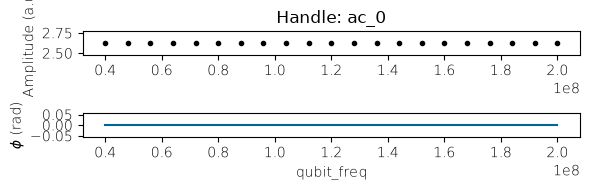

In [12]:
# set calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calib)
exp_qspec.set_signal_map(map_q0)

# create a session and connect to it
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

# run experiment on qubit 0
qspec_results = session.run(exp_qspec)

# plot measurement results
plot_results(qspec_results, phase=True)

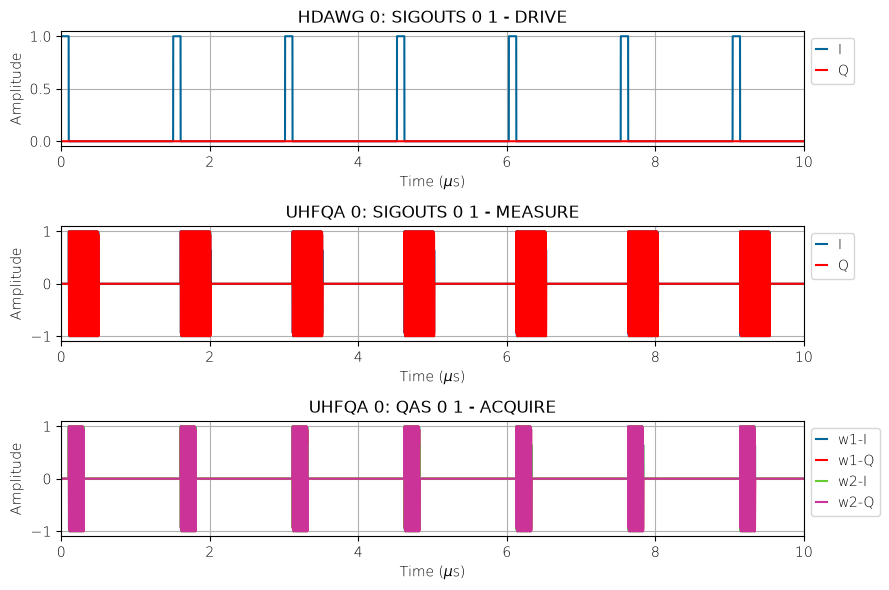

In [13]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)